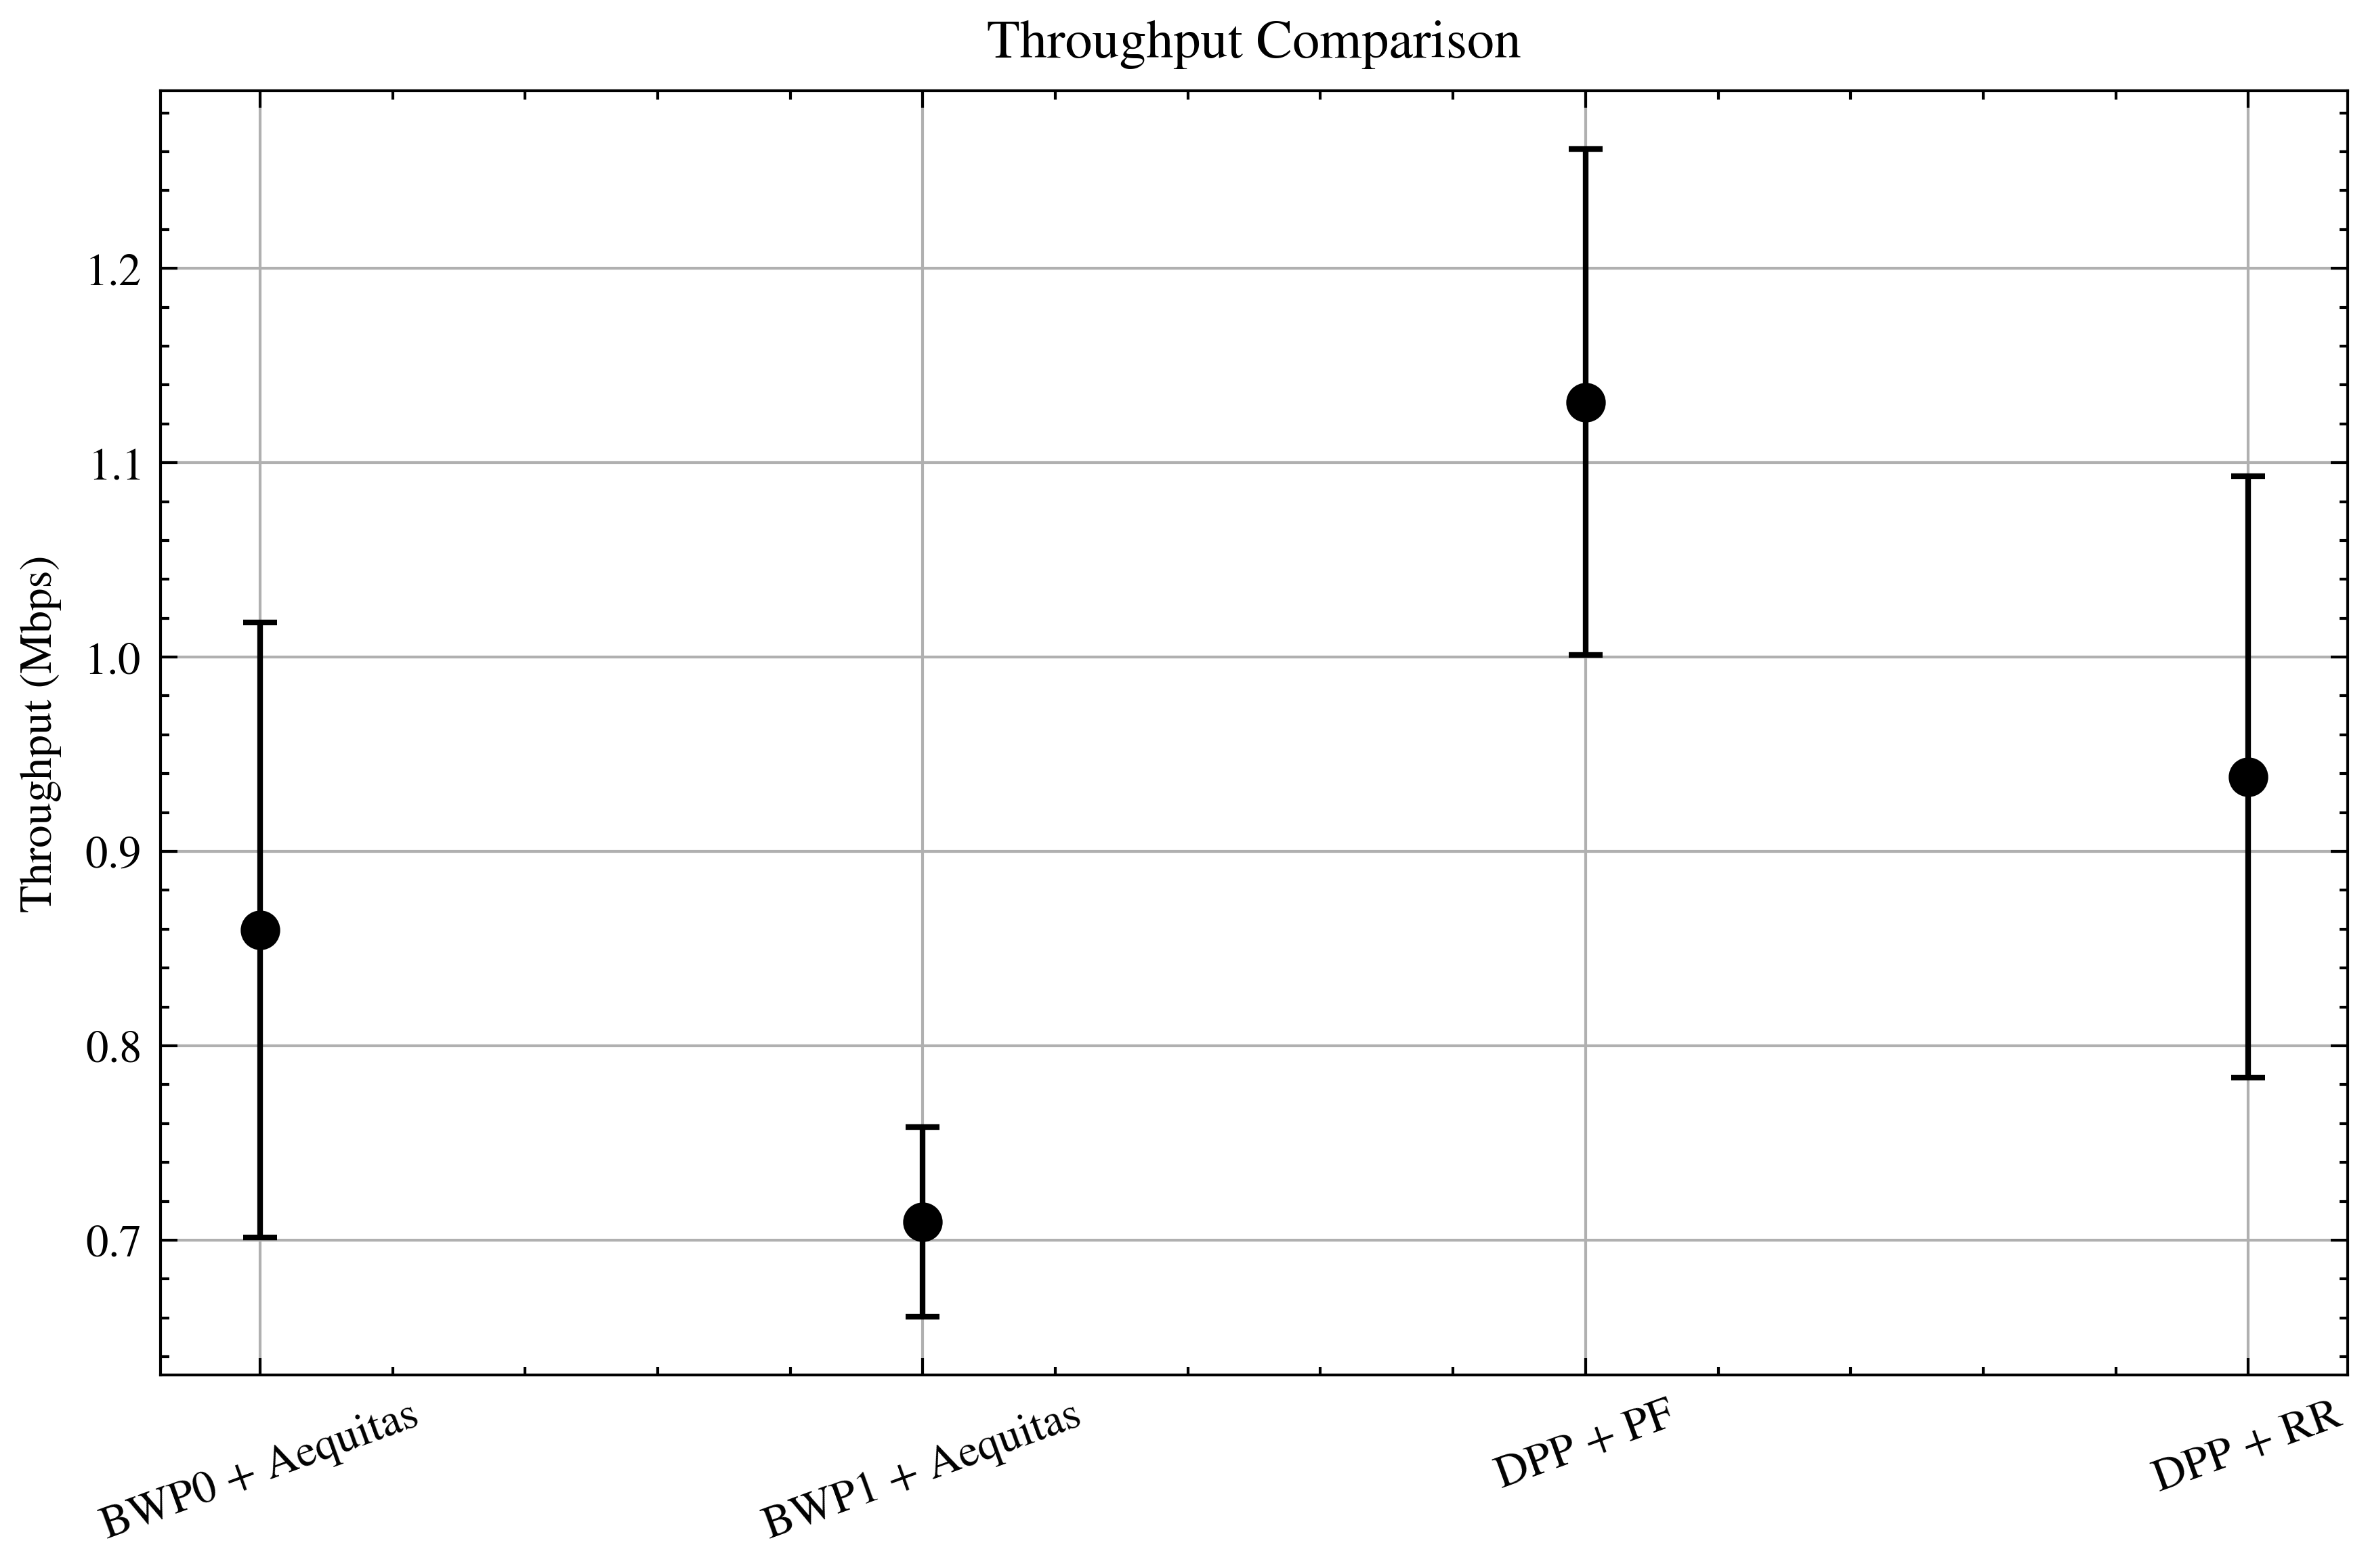

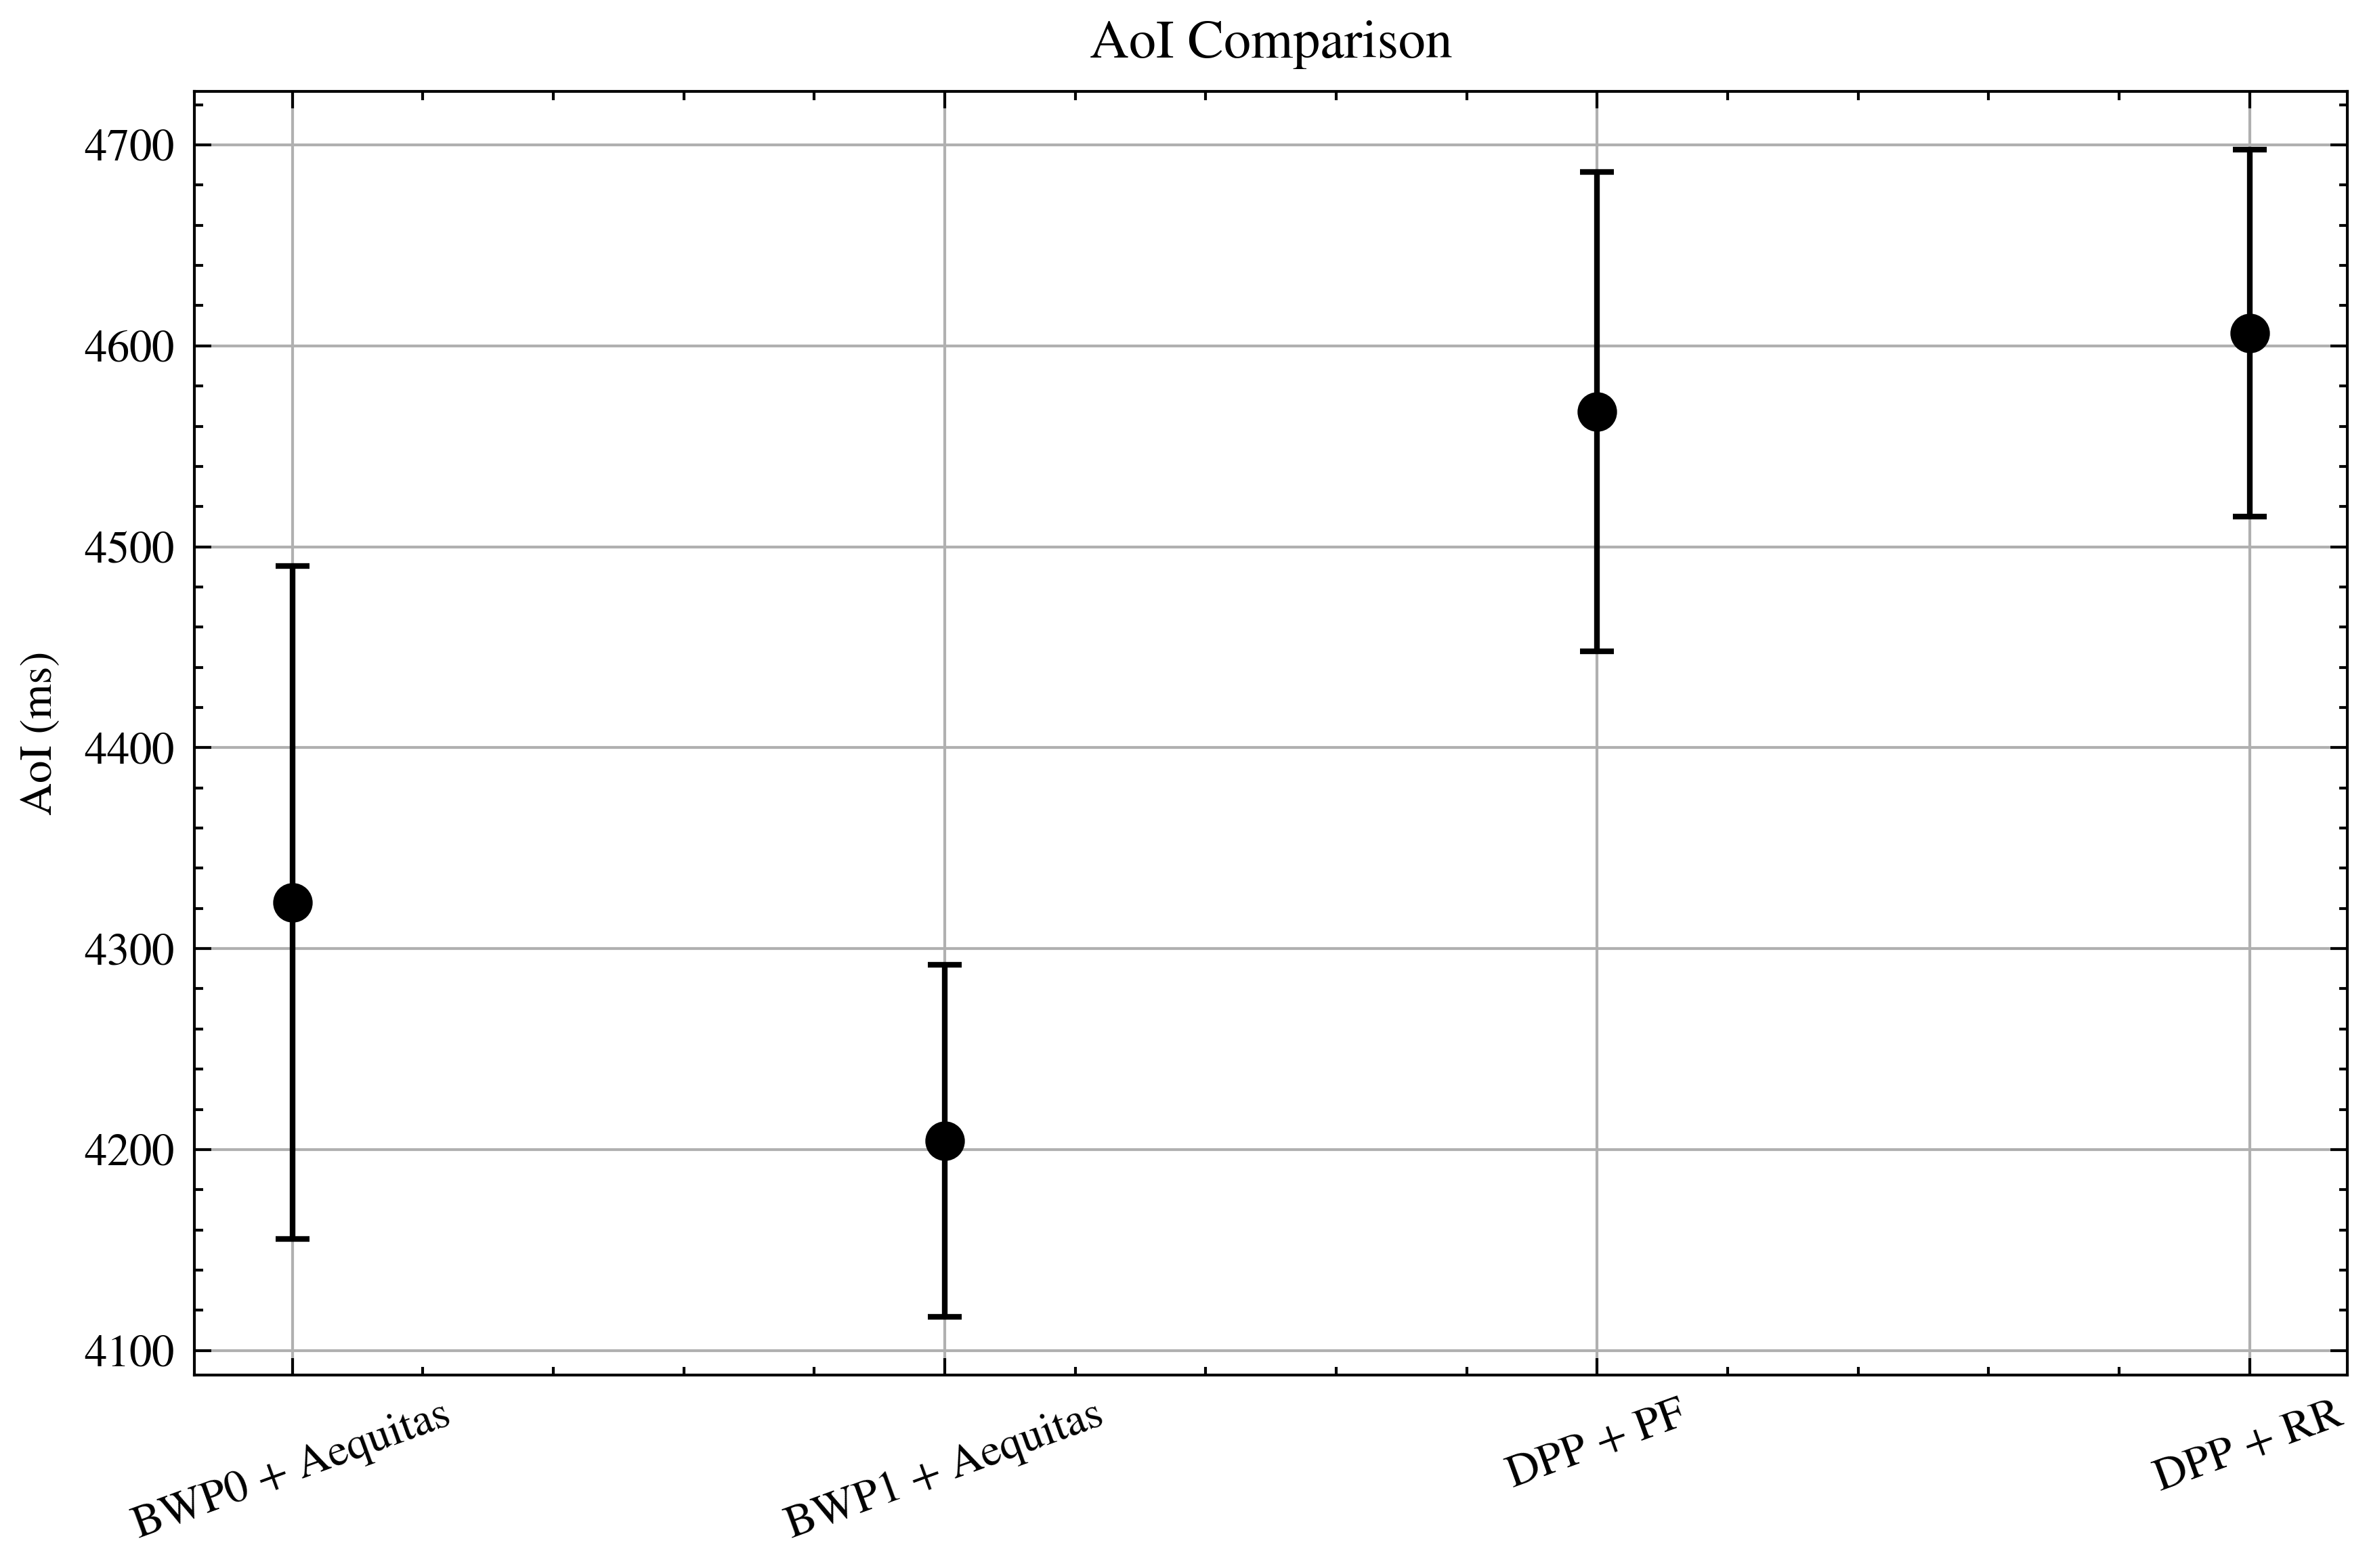


=== Summary ===
BWP0 + Aequitas
  Throughput: 0.8596 ± 0.1582
  AoI       : 4323.00 ± 167.49
BWP1 + Aequitas
  Throughput: 0.7095 ± 0.0488
  AoI       : 4204.47 ± 87.59
DPP + PF
  Throughput: 1.1311 ± 0.1302
  AoI       : 4567.36 ± 119.25
DPP + RR
  Throughput: 0.9384 ± 0.1547
  AoI       : 4606.38 ± 91.21


In [6]:
#!/usr/bin/env python3

import os
import glob
import math
import statistics
import matplotlib.pyplot as plt
import scienceplots

# =========================
# 설정
# =========================
plt.style.use(["science", "ieee", "no-latex"])
DATA_DIR = "."

# =========================
# key=value 파서
# =========================
def try_number(x):
    x = x.strip()
    try:
        if any(c in x for c in [".", "e", "E"]):
            return float(x)
        return int(x)
    except:
        return x

def parse_kv_file(path):
    with open(path, "r") as f:
        text = f.read().strip()

    row = {}
    for item in text.split(","):
        if "=" not in item:
            continue
        k, v = item.split("=", 1)
        row[k.strip()] = try_number(v)
    return row

def load_group(pattern):
    files = sorted(glob.glob(os.path.join(DATA_DIR, pattern)))
    if not files:
        raise FileNotFoundError(pattern)
    return [parse_kv_file(f) for f in files]

# =========================
# 통계
# =========================
def get_vals(rows, key):
    vals = []
    for r in rows:
        if key in r and isinstance(r[key], (int, float)):
            vals.append(float(r[key]))
    return vals

def mean_std(vals):
    mean = statistics.mean(vals)
    std = statistics.stdev(vals) if len(vals) >= 2 else 0.0
    return mean, std

# =========================
# 데이터 로드
# =========================
groups = {
    "BWP0 + Aequitas": "bwp0_aequitas_*.csv",
    "BWP1 + Aequitas": "bwp1_aequitas_*.csv",
    "DPP + PF": "dpp_pf_*.csv",
    "DPP + RR": "dpp_rr_*.csv",
}

results = {}

for name, pattern in groups.items():
    rows = load_group(pattern)

    thr_vals = get_vals(rows, "runMeanThrMbps")
    aoi_vals = get_vals(rows, "runMeanAoiMs")

    results[name] = {
        "thr_mean": mean_std(thr_vals)[0],
        "thr_std": mean_std(thr_vals)[1],
        "aoi_mean": mean_std(aoi_vals)[0],
        "aoi_std": mean_std(aoi_vals)[1],
    }

labels = list(results.keys())
x = range(len(labels))

# =========================
# 1) Throughput 그래프
# =========================
thr_means = [results[k]["thr_mean"] for k in labels]
thr_stds  = [results[k]["thr_std"] for k in labels]

plt.figure(figsize=(6, 4))
plt.errorbar(x, thr_means, yerr=thr_stds, fmt='o', capsize=3)
plt.xticks(x, labels, rotation=20)
plt.ylabel("Throughput (Mbps)")
plt.title("Throughput Comparison")
plt.grid(True)

plt.tight_layout()
plt.savefig("throughput_plot.png", dpi=300)
plt.savefig("throughput_plot.pdf", dpi=300)
plt.show()

# =========================
# 2) AoI 그래프
# =========================
aoi_means = [results[k]["aoi_mean"] for k in labels]
aoi_stds  = [results[k]["aoi_std"] for k in labels]

plt.figure(figsize=(6, 4))
plt.errorbar(x, aoi_means, yerr=aoi_stds, fmt='o', capsize=3)
plt.xticks(x, labels, rotation=20)
plt.ylabel("AoI (ms)")
plt.title("AoI Comparison")
plt.grid(True)

plt.tight_layout()
plt.savefig("aoi_plot.png", dpi=300)
plt.savefig("aoi_plot.pdf", dpi=300)
plt.show()

# =========================
# 콘솔 출력
# =========================
print("\n=== Summary ===")
for name in labels:
    r = results[name]
    print(f"{name}")
    print(f"  Throughput: {r['thr_mean']:.4f} ± {r['thr_std']:.4f}")
    print(f"  AoI       : {r['aoi_mean']:.2f} ± {r['aoi_std']:.2f}")